<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_06_Graduate_Admission_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv('/content/Graduate_Admission_Predict.csv')

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
df['Change Of Admit'] = df['Chance of Admit'].apply(lambda x: 1 if x >= 0.8 else 0)

In [ ]:
x = df.drop(['Serial No.', 'Chance of Admit', 'Change Of Admit'], axis=1)
y = df['Change Of Admit']

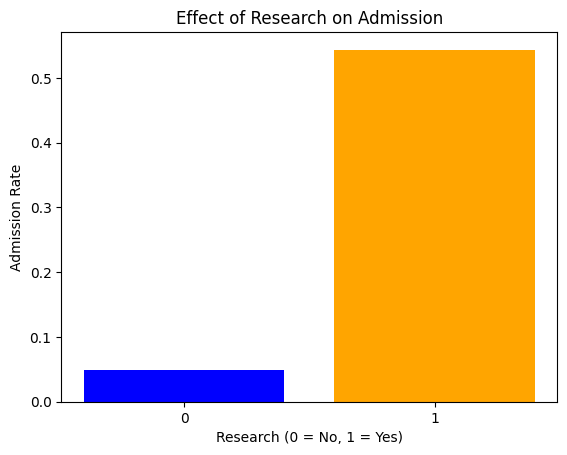

In [ ]:
research_admit = df.groupby('Research')['Change Of Admit'].mean()

plt.bar(
    research_admit.index.astype(str),
    research_admit.values,
    color=['blue', 'orange']
)

plt.xlabel('Research (0 = No, 1 = Yes)')
plt.ylabel('Admission Rate')
plt.title('Effect of Research on Admission')

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [ ]:
X = scaler.fit_transform(x)

In [ ]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
df_compare = pd.DataFrame({'Actual': y_test,'Predicted':y_pred})
df_compare

,Actual,Predicted
255,0,0
346,0,0
228,0,0
384,1,1
269,0,0
...,...,...
320,0,0
73,1,0
79,0,0
390,0,0


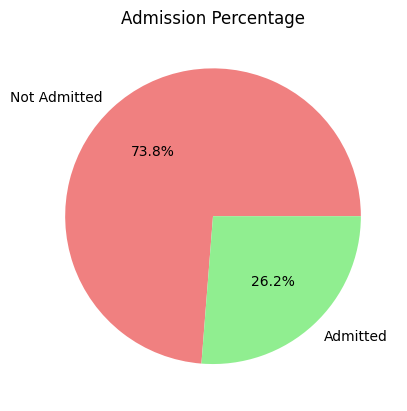

In [ ]:
counts = df_compare['Actual'].value_counts().sort_index()

plt.pie(
    counts.values,
    labels=['Not Admitted', 'Admitted'],
    autopct='%1.1f%%',
    colors=['lightcoral', 'lightgreen']
)

plt.title('Admission Percentage')
plt.show()

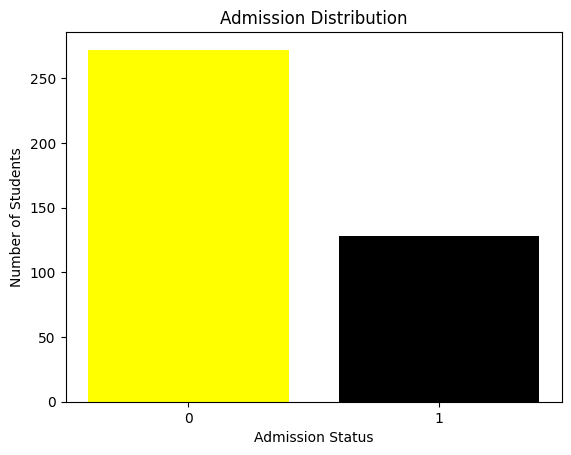

In [ ]:
target_counts = df['Change Of Admit'].value_counts()

plt.bar(
    target_counts.index.astype(str),
    target_counts.values,
    color=['yellow', 'black']
)

plt.xlabel('Admission Status')
plt.ylabel('Number of Students')
plt.title('Admission Distribution')

plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy is", accuracy)

Accuracy is 0.8875


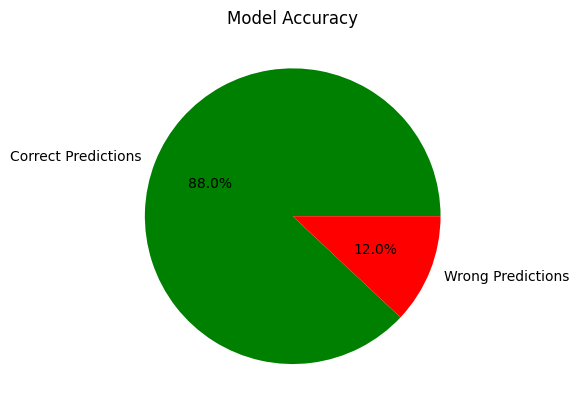

In [ ]:
import matplotlib.pyplot as plt

accuracy = 0.88
error = 1 - accuracy

plt.pie(
    [accuracy, error],
    labels=['Correct Predictions', 'Wrong Predictions'],
    autopct='%1.1f%%',
    colors=['green', 'red']
)

plt.title('Model Accuracy')
plt.show()

# TEST

In [ ]:
test =[5,314,104,2,2.0,2.5,8.00]
print(knn.predict([test]))

[1]


In [ ]:
test =[337,118,4,3.0,4.00,9.00,1]

m = scaler.transform([test])

n = knn.predict(m)

if n == 1:

    print('admitted')

else:

    print('not admitted')

admitted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
test =[300,103,1,2.0,2.0,7.50,0]

m = scaler.transform([test])

n = knn.predict(m)

if n == 1:

    print('admitted')

else:

    print('not admitted')

not admitted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
